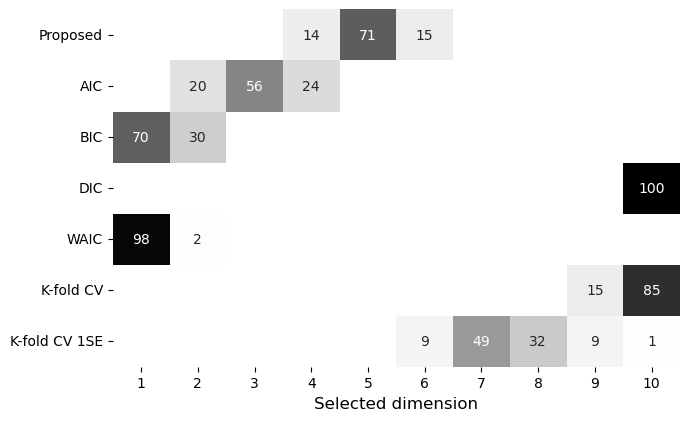

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

methods = [
    "Proposed",
    "AIC",
    "BIC",
    "DIC",
    "WAIC",
    "K-fold CV",
    "K-fold CV 1SE",
]

dims = np.arange(1, 11)

# load data

annotations = data.copy().astype(str)
annotations[data == 0] = ""


fig, ax = plt.subplots(figsize=(7,5))

ax = sns.heatmap(
    data,
    annot=annotations,
    fmt="",
    cmap="Greys",
    cbar=False,
    linewidths=0,
    xticklabels=dims,
    yticklabels=methods,
    annot_kws={"size": 10},
    vmin=0, vmax=100
)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')


ax.set_aspect(0.9)
ax.set_xlabel("Selected dimension", fontsize=12)

plt.tight_layout()
plt.show()

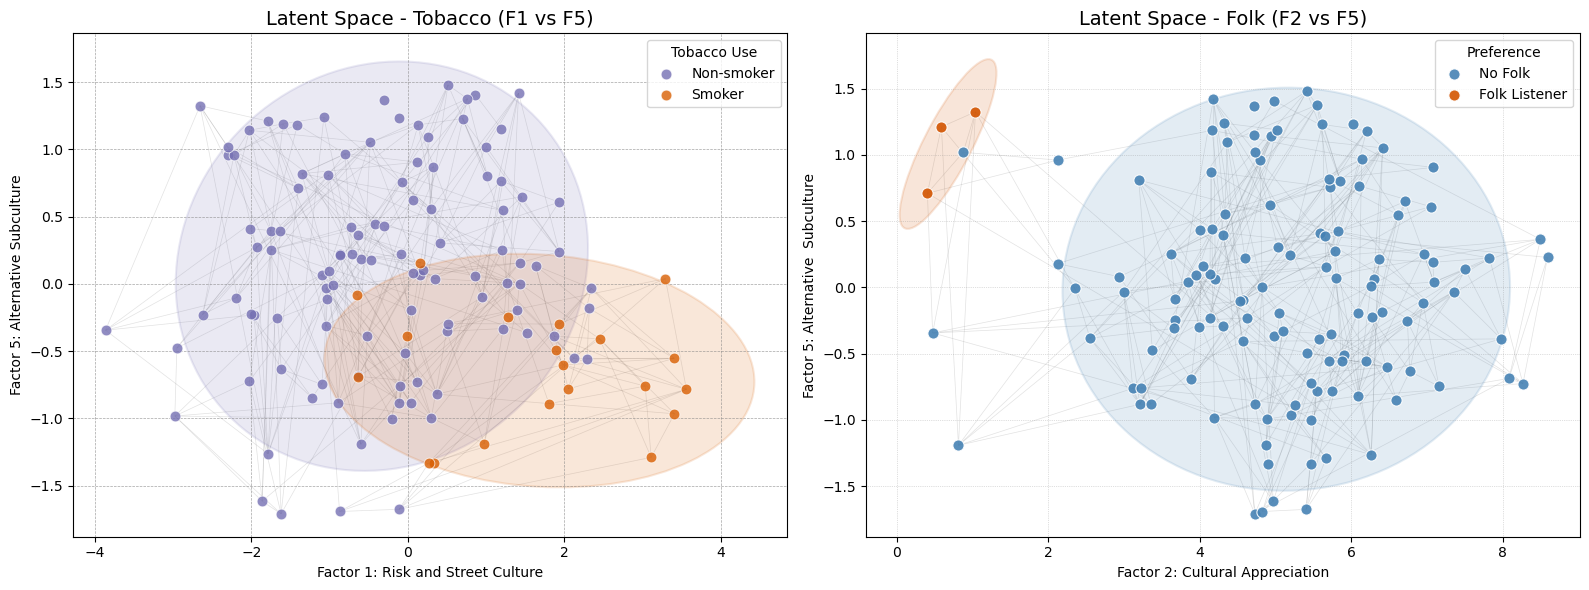

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.collections import LineCollection
import numpy as np

def add_confidence_ellipse(ax, x, y, color, label=None, n_std=1.96, **kwargs):

    if x.size < 3: 
        return
        
    cov = np.cov(x,y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * np.sqrt(vals) * n_std
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    ellip = Ellipse(xy=(mean_x, mean_y), width=width, height=height, angle=theta,
                    edgecolor=color, facecolor=color, alpha=0.15, lw=1.5)
    ax.add_patch(ellip)



fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]

df_merged = pd.merge(Z_df, Y_df, on='id')




pos_dict = df_merged.set_index('id')[['F1', 'F5']].T.to_dict('list')


group_configs = [
    #{'ids': [NA], 'color': '#999999', 'label': 'Miss', 'alpha': 0.5},  #
    {'ids': [1], 'color': '#7570B3', 'label': 'Non-smoker', 'alpha': 0.8},
    {'ids': [2, 3], 'color': '#D95F02', 'label': 'Smoker', 'alpha': 0.8}
]



lines = []
for _, row in edges_df.iterrows():
    u, v = row['from'], row['to']
    if u in pos_dict and v in pos_dict:
        lines.append([pos_dict[u], pos_dict[v]])

lc = LineCollection(lines, colors='#707070', linewidths=0.5, alpha=0.2, zorder=1)
ax.add_collection(lc)

for config in group_configs:

    subset = df_merged[df_merged['tobacco'].isin(config['ids'])]
    if not subset.empty:
        add_confidence_ellipse(
            ax, 
            subset['F1'], 
            subset['F5'], 
            color=config['color']
        )


for config in group_configs:
    subset = df_merged[df_merged['tobacco'].isin(config['ids'])]
    ax.scatter(
        subset['F1'], 
        subset['F5'], 
        c=config['color'], 
        label=config['label'],
        s=60, 
        alpha=0.8, 
        edgecolors='white', 
        linewidth=0.6,
        zorder=3
    )



ax.set_title("Latent Space - Tobacco (F1 vs F5)", fontsize=14)
ax.set_xlabel("Factor 1: Risk and Street Culture")
ax.set_ylabel("Factor 5: Alternative Subculture")


ax.grid(True, which='both', axis='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(title="Tobacco Use", loc='upper right', frameon=True, fontsize=10)

ax.autoscale_view()


ax = axes[1]


unique_vals = sorted(df_merged['folk'].unique())
no_folk_val = unique_vals[0]
yes_folk_val = unique_vals[1] if len(unique_vals) > 1 else unique_vals[0]


color_map = {
    no_folk_val: '#4682B4',  
    yes_folk_val: '#D35400'  #
}

label_map = {
    no_folk_val: 'No Folk',
    yes_folk_val: 'Folk Listener'
}


pos_dict = df_merged.set_index('id')[['F2', 'F5']].T.to_dict('list')

lines = []
for _, row in edges_df.iterrows():
    u, v = row['from'], row['to']
    if u in pos_dict and v in pos_dict:

        p1 = pos_dict[u] 
        p2 = pos_dict[v] 
        lines.append([p1, p2])


lc = LineCollection(lines, colors='#707070', linewidths=0.5, alpha=0.2, zorder=1)
ax.add_collection(lc)


for group_id in unique_vals:
    subset = df_merged[df_merged['folk'] == group_id]
    if not subset.empty:
        add_confidence_ellipse(
            ax, 
            subset['F2'], 
            subset['F5'], 
            color=color_map[group_id],
            n_std=1.96 #
        )


for group_id in unique_vals:
    subset = df_merged[df_merged['folk'] == group_id]
    ax.scatter(
        subset['F2'], 
        subset['F5'], 
        c=color_map[group_id], 
        label=label_map[group_id],
        s=65,       # 
        alpha=0.9,  
        edgecolors='white', 
        linewidth=0.8,
        zorder=3
    )


ax.set_title("Latent Space - Folk (F2 vs F5)", fontsize=14)
ax.set_xlabel("Factor 2: Cultural Appreciation")
ax.set_ylabel("Factor 5: Alternative  Subculture")


ax.grid(True, which='both', axis='both', color='gray', linestyle=':', linewidth=0.5, alpha=0.5)




ax.legend(title="Preference", loc='upper right', frameon=True, fontsize=10)

#
ax.autoscale_view()






plt.tight_layout()
plt.show()